## Treinamento do modelo Regressão Logística

Objetivos deste notebook: 
- Preparar e padronizar as features para evitar vazamento de dados
- Treinar o modelo de Regressão Logística para classificação multiclasse do perfil de consumo.
- Avaliar o desempenho do modelo utilizando métricas de classificação (Acurácia, Precision, Recall e F1-Score) e Matriz de Confusão.
- Interpretar a relevância das variáveis preditoras (coeficientes) no consumo energético.
- Apresentar um relatório geral sobre o processo de treinamento e eficiência do modelo. 

## Etapa 1 — Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


### Etapa 1.1 — Carregamento e exploração de dados

Carregando o Dataset de entrada: ``energiai_dataset_v1.csv`` construído a partir da etapa anterior(contida em "../notebooks/01_dataset.ipynb") e explorando o formato dos dados.

O resultado: 479 linhas, 8 colunas, tipos de dado corretos (incluindo ``uso_horario_pico`` já como bool nativo, inferido automaticamente pelo Pandas na leitura do CSV).



In [2]:
dados = pd.read_csv("../data/processed/energiai_dataset_v1.csv")

print(f"Shape do dataset: {dados.shape}")
print(f"\nTipos de dado:")
print(dados.dtypes)
print(f"\nAmostra:")
dados.head()

Shape do dataset: (479, 8)

Tipos de dado:
meter_id                       str
consumo_kwh                float64
horas_alto_consumo         float64
uso_horario_pico              bool
tipo_imovel                    str
quantidade_equipamentos      int64
categoria                      str
custo_estimado_mensal      float64
dtype: object

Amostra:


,meter_id,consumo_kwh,horas_alto_consumo,uso_horario_pico,tipo_imovel,quantidade_equipamentos,categoria,custo_estimado_mensal
0,MAC000002,360.082000,7.183168,True,Casa,8,Ineficiente,270.06
1,MAC000003,441.140001,4.742568,False,Casa,16,Moderado,330.86
2,MAC000004,50.913500,5.017372,False,Apartamento,3,Eficiente,38.19
3,MAC000006,87.027500,9.070302,False,Apartamento,6,Eficiente,65.27
4,MAC000007,270.542500,6.805927,True,Apartamento,8,Ineficiente,202.91


## Etapa 2 — Preparação das variáveis de entrada(x) e do alvo(y)

Dividimos o dataset em **variáveis de entrada(x)**, utilizadas pelo modelo para realizar as previsões, e na **variável alvo(y)**, correspondente à categoria de eficiência que o modelo deverá prever. 

#### Decisões técnicas:
- Codificação de ``tipo_imovel`` com ``get_dummies``: como as categorias **Apartamento, Casa e Comércio** não possuem uma ordem natural, utilizar valores numéricos como 0, 1 e 2 criaria uma relação de ordem inexistente. O ``get_dummies`` transforma a variável em **três colunas binárias independentes**, evitando essa interpretação equivocada pelo modelo.

- Criação da feature ``consumo_por_equipamento``: calculada pela razão ``consumo_kwh / quantidade_equipamentos``. Como a Regressão Logística trabalha com **combinações lineares das features** fornecidas, ela não identifica automaticamente essa relação entre duas variáveis. A criação dessa feature permite que o modelo utilize diretamente uma relação que já possui relevância no score utilizado para gerar as categorias.
    
- Exclusão de ``meter_id``, ``custo_estimado_mensal`` e ``categoria``: ``meter_id`` foi removido por ser apenas um identificador, sem valor preditivo; ``custo_estimado_mensal`` foi excluído por apresentar correlação perfeita com ``consumo_kwh``, sendo uma variável redundante; e ``categoria`` foi retirada de **X** por ser o target que o modelo deve aprender a prever.

Dessa forma, **x** ficou composto por **8 features**: ``consumo_kwh``, ``horas_alto_consumo``, ``uso_horario_pico``, ``quantidade_equipamentos``, ``consumo_por_equipamento`` e as três variáveis binárias referentes ao ``tipo_imovel``.
O target **y** permaneceu balanceado, com 144 domicílios Eficientes, 191 Moderados e 144 Ineficientes, mantendo a distribuição aproximadamente 30% / 40% / 30%.


In [3]:
# construção da feature "consumo_por_equipamento" utilizando a mesma razão usada para construir o score/rótulo original
dados["consumo_por_equipamento"] = dados["consumo_kwh"] / dados["quantidade_equipamentos"]

# transformação de tipo_imovel em colunas binárias
dados_codificado = pd.get_dummies(dados, columns=["tipo_imovel"], prefix="tipo_imovel")

# define as features (X) excluindo as classes desnecessárias
colunas_excluir = ["meter_id", "categoria", "custo_estimado_mensal"]
X = dados_codificado.drop(columns=colunas_excluir)
y = dados_codificado["categoria"]

print("Colunas de X (features):")
print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print("\nDistribuição de y:")
print(y.value_counts())
X.head()

Colunas de X (features):
['consumo_kwh', 'horas_alto_consumo', 'uso_horario_pico', 'quantidade_equipamentos', 'consumo_por_equipamento', 'tipo_imovel_Apartamento', 'tipo_imovel_Casa', 'tipo_imovel_Comercio']

Shape de X: (479, 8)
Shape de y: (479,)

Distribuição de y:
categoria
Moderado       191
Ineficiente    144
Eficiente      144
Name: count, dtype: int64


,consumo_kwh,horas_alto_consumo,uso_horario_pico,quantidade_equipamentos,consumo_por_equipamento,tipo_imovel_Apartamento,tipo_imovel_Casa,tipo_imovel_Comercio
0,360.082000,7.183168,True,8,45.010250,False,True,False
1,441.140001,4.742568,False,16,27.571250,False,True,False
2,50.913500,5.017372,False,3,16.971167,True,False,False
3,87.027500,9.070302,False,6,14.504583,True,False,False
4,270.542500,6.805927,True,8,33.817812,True,False,False


## Etapa 3 — Divisão dos dados em treino e teste

Separamos os 479 domicílios em dois subconjuntos: o conjunto de **treino**, utilizado pelo modelo para aprender os padrões dos dados, e o conjunto de **teste**, utilizado para avaliar o desempenho do modelo em dados que não foram utilizados durante o treinamento. Dessa forma evitando que o modelo simplesmente se ajuste aos exemplos que já conhece, sem necessariamente conseguir generalizar para novos casos.

Para evitar que a divisão aleatória alterasse a distribuição das categorias, foi utilizado o parâmetro ``stratify=y``, que mantém aproximadamente a mesma proporção de classes nos dois conjuntos.

Nessa divisão foram destinados **383 domicílios para treinamento (80%) e 96 para teste (20%)**. As proporções das categorias permaneceram praticamente idênticas nos dois grupos, **mantendo a distribuição aproximada de 30% Eficiente, 40% Moderado e 30% Ineficiente**, graças ao ``stratify=y``.



In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42, # garante que a divisão seja sempre a mesma, reproduzível
    stratify=y
)

print(f"Treino: {X_train.shape[0]} residências")
print(f"Teste: {X_test.shape[0]} residências")

print("\nDistribuição de categoria no treino:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribuição de categoria no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: 383 residências
Teste: 96 residências

Distribuição de categoria no treino:
categoria
Moderado       0.399
Ineficiente    0.300
Eficiente      0.300
Name: proportion, dtype: float64

Distribuição de categoria no teste:
categoria
Moderado       0.396
Eficiente      0.302
Ineficiente    0.302
Name: proportion, dtype: float64


## Etapa 4 — Padronização das features

Nesta etapa, as 8 features de entrada são padronizadas para uma escala comum usando ``StandardScaler``, transformando cada variável de modo que apresente média próxima de 0 e desvio-padrão próximo de 1. Essa transformação é importante porque as variáveis originais possuem magnitudes muito diferentes, como ``consumo_kwh``, que pode assumir valores na casa das centenas, e ``uso_horario_pico``, que assume apenas valores entre 0 e 1.

Essa padronização evita que variáveis com valores numericamente maiores dominem o ajuste dos coeficientes da Regressão Logística apenas devido à sua escala, garantindo uma comparação mais adequada entre as features. Além disso, o ``StandardScaler`` é ajustado exclusivamente com os dados de treino e, posteriormente, a mesma transformação é aplicada ao conjunto de teste. Isso evita data leakage(vazamento de dados), pois informações estatísticas do conjunto de teste não podem influenciar o processo de treinamento.


In [5]:
scaler = StandardScaler()

# aprende e transforma média/desvio só no treino 
X_train_scaled = scaler.fit_transform(X_train)

# aplica a mesma transformação aprendida no treino, sobre o teste
X_test_scaled = scaler.transform(X_test)

# transforma em DataFrame para facilitar a visualização
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Antes da padronização (treino):")
print(X_train.describe().loc[["mean", "std"]].round(2))

print("\nDepois da padronização (treino):")
print(X_train_scaled.describe().loc[["mean", "std"]].round(2))

Antes da padronização (treino):
      consumo_kwh  horas_alto_consumo  quantidade_equipamentos  \
mean       289.44                8.00                     8.35   
std        181.84                1.71                     4.57   

      consumo_por_equipamento  
mean                    35.08  
std                     13.63  

Depois da padronização (treino):
      consumo_kwh  horas_alto_consumo  uso_horario_pico  \
mean         -0.0                 0.0              -0.0   
std           1.0                 1.0               1.0   

      quantidade_equipamentos  consumo_por_equipamento  \
mean                      0.0                     -0.0   
std                       1.0                      1.0   

      tipo_imovel_Apartamento  tipo_imovel_Casa  tipo_imovel_Comercio  
mean                      0.0               0.0                  -0.0  
std                       1.0               1.0                   1.0  


## Etapa 5 — Treinamento do modelo de Regressão Logística

Nesta etapa ocorre o **treinamento efetivo do modelo**, no qual ele ajusta os pesos dos parâmetros para aprender a relação entre as features de entrada e as três categorias de eficiência. Para cada domicílio, o modelo calcula pontuações para as classes e utiliza a função **softmax** para convertê-las em probabilidades que, juntas, somam 100%.

Observa-se que o modelo apresentou convergência rápida, necessitando de apenas 27 das 1000 iterações disponíveis para encontrar uma solução estável. Isso indica que o algoritmo conseguiu ajustar os parâmetros sem dificuldades de convergência, não sendo necessário utilizar todo o limite de iterações definido.

In [6]:
modelo_lr = LogisticRegression(
    max_iter=1000, # margem de segurança para que o algoritmo possa realizar mais iterações caso necessário para alcançar a convergência
    random_state=42 # garante a reproduzibilidade
)

modelo_lr.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso.")
print(f"\nClasses aprendidas: {modelo_lr.classes_}")
print(f"\nNúmero de iterações até convergir: {modelo_lr.n_iter_}")

Modelo treinado com sucesso.

Classes aprendidas: ['Eficiente' 'Ineficiente' 'Moderado']

Número de iterações até convergir: [27]


## Etapa 6 — Avaliação do modelo

Avaliamos o desempenho do modelo utilizando os 96 domicílios do conjunto de teste. Para realizar essa avaliação, foram utilizadas duas ferramentas principais:

- **Classification Report**: apresenta métricas de desempenho para cada categoria — precisão (precision), recall e F1-score — em vez de considerar apenas a acurácia geral. Isso é importante porque uma acurácia alta pode esconder um desempenho ruim em uma categoria específica.
- **Matriz de Confusão**: permite identificar quais categorias o modelo está confundindo entre si, mostrando não apenas a quantidade de erros, mas também onde esses erros estão ocorrendo.

**Resultados**: 
- O modelo apresentou uma acurácia geral de 95,8%. A categoria "Ineficiente" apresentou o melhor desempenho entre as três categorias, com precisão de 1,00 e recall de 0,97.
- A matriz de confusão também mostrou que não houve nenhuma confusão entre as categorias extremas Eficiente e Ineficiente. Os 4 erros totais ocorreram somente entre categorias vizinhas.


    Obs: Apesar do desempenho elevado, **esse resultado é esperado**, e não representa necessariamente uma evidência de forte generalização para padrões desconhecidos do mundo real. A categoria foi construída a partir de uma combinação quase linear das mesmas variáveis utilizadas no treinamento. Dessa forma, o resultado positivo reflete principalmente a qualidade da engenharia de features e da construção do problema, mais do que uma comprovação de que o modelo generaliza para situações reais e desconhecidas.



In [7]:
y_pred = modelo_lr.predict(X_test_scaled)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia geral: {acuracia:.3f}\n")

print("Relatório de classificação (por categoria):")
print(classification_report(y_test, y_pred))

Acurácia geral: 0.958

Relatório de classificação (por categoria):
              precision    recall  f1-score   support

   Eficiente       0.96      0.93      0.95        29
 Ineficiente       1.00      0.97      0.98        29
    Moderado       0.93      0.97      0.95        38

    accuracy                           0.96        96
   macro avg       0.96      0.96      0.96        96
weighted avg       0.96      0.96      0.96        96



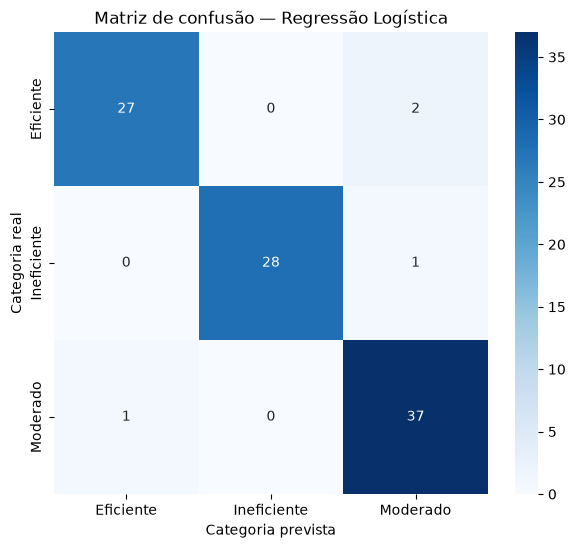

In [8]:
matriz = confusion_matrix(y_test, y_pred, labels=modelo_lr.classes_)

plt.figure(figsize=(7, 6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_)
plt.xlabel("Categoria prevista")
plt.ylabel("Categoria real")
plt.title("Matriz de confusão — Regressão Logística")
plt.show()

## Etapa 7 — Interpretação dos coeficientes

Nesta etapa analisamos os **pesos que o modelo aprendeu para cada variável em cada uma das três categorias**. Esses coeficientes são os valores utilizados diretamente no cálculo das probabilidades: cada peso é multiplicado pelo valor da variável, os resultados são somados e, posteriormente, o ``softmax`` transforma essas pontuações em probabilidades. 

**Resultados:**

Para a categoria **"Ineficiente"**, as variáveis com maiores coeficientes foram:

1. ``uso_horario_pico`` -> 3,05
2. ``consumo_kwh`` -> 2,96
3. ``consumo_por_equipamento`` -> 2,23

Esse resultado é parcialmente diferente do que seria esperado a partir da fórmula manual do score utilizada anteriormente. Nessa fórmula, ``uso_horario_pico`` recebia peso 0,1, sendo o menor peso entre as quatro variáveis.

Essa diferença pode ser explicada por **dois fatores técnicos**:

- **Padronização da variável binária**: ao padronizar uma variável binária, o salto de ``False`` para ``True`` representa uma transição de aproximadamente um desvio-padrão. Isso tende a produzir coeficientes maiores para esse tipo de variável quando comparados diretamente com variáveis contínuas.
- **Separação das categorias nos dados**: nos dados analisados, ``uso_horario_pico`` separou as categorias de maneira bastante nítida. Apenas 4% dos domicílios Eficientes apresentavam ``uso_horario_pico=True``, enquanto essa proporção chegava a 51% nos domicílios Ineficientes. Esse comportamento, observado anteriormente na análise exploratória dos dados (EDA), fez com que **o modelo aprendesse diretamente a força dessa variável a partir dos dados, independentemente do peso atribuído a ela na fórmula manual original**.

Assim, os coeficientes mostram quais variáveis o modelo efetivamente considerou mais relevantes para a classificação, permitindo interpretar sua decisão com base no próprio comportamento aprendido durante o treinamento.

Coeficientes por categoria (pesos aprendidos):
             consumo_kwh  horas_alto_consumo  uso_horario_pico  \
Eficiente         -2.674              -1.570            -3.141   
Ineficiente        2.957               1.433             3.047   
Moderado          -0.283               0.137             0.093   

             quantidade_equipamentos  consumo_por_equipamento  \
Eficiente                     -1.634                   -2.499   
Ineficiente                    1.378                    2.229   
Moderado                       0.255                    0.270   

             tipo_imovel_Apartamento  tipo_imovel_Casa  tipo_imovel_Comercio  
Eficiente                      0.440            -0.163                -0.432  
Ineficiente                   -0.454             0.171                 0.440  
Moderado                       0.014            -0.009                -0.009  


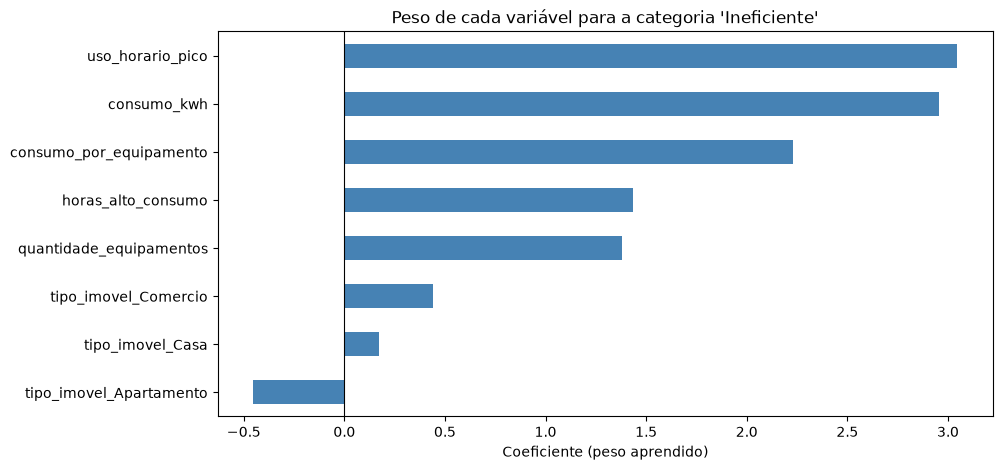

In [9]:
coeficientes = pd.DataFrame(
    modelo_lr.coef_,
    columns=X.columns,
    index=modelo_lr.classes_
)

print("Coeficientes por categoria (pesos aprendidos):")
print(coeficientes.round(3))

# visualização de quais variáveis mais empurram para ineficiente
plt.figure(figsize=(10, 5))
coeficientes.loc["Ineficiente"].sort_values().plot(kind="barh", color="steelblue")
plt.title("Peso de cada variável para a categoria 'Ineficiente'")
plt.xlabel("Coeficiente (peso aprendido)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

## Etapa 8 — Relatório Geral de Treinamento e Avaliação dos Resultados

### **1. Preparação de Dados e Metodologia** 

Para o treinamento do modelo, o dataset contendo 479 registros foi dividido em conjuntos de treino (80%), contendo 383 domicílios, e teste (20%), contendo 96 domicílios, utilizando o parâmetro de estratificação para manter a proporção original das classes (Eficiente, Moderado e Ineficiente) em ambos os subconjuntos.  A fim de evitar que variáveis com valores numericamente maiores dominassem o ajuste dos coeficientes, foi aplicado o ``StandardScaler``. A padronização foi ajustada exclusivamente com os dados de treino e posteriormente aplicada ao conjunto de teste, garantindo a prevenção de vazamento de dados (data leakage).

### **2. Desempenho e Validação do Modelo**

O algoritmo apresentou uma convergência rápida, necessitando de apenas **27 iterações para encontrar uma solução estável**. A avaliação no conjunto de teste demonstrou os seguintes resultados:  
- **Acurácia Geral**: O modelo obteve um índice de acerto de 95,8%.  
- **Classification Report**: O melhor desempenho ocorreu na categoria "Ineficiente", alcançando precisão de 1,00 e recall de 0,97. As categorias "Eficiente" e "Moderado" também mantiveram um alto nível de generalização, ambas registrando um F1-score de 0,95.  
- **Matriz de Confusão**: A análise da matriz indicou que não houve erros de classificação entre as classes extremas (Eficiente vs. Ineficiente). Os únicos 4 erros observados ocorreram entre categorias vizinhas (ex: Eficiente sendo classificado como Moderado).  

### **3. Interpretação dos Coeficientes**

Uma característica técnica vantajosa da Regressão Logística é a sua alta interpretabilidade, permitindo analisar os pesos que o modelo atribuiu para cada variável no cálculo das probabilidades (via função softmax).
Para a categoria "Ineficiente", as variáveis preditoras com maior impacto foram, em ordem de relevância:
1. ``uso_horario_pico`` -> (coeficiente: 3,05).  
2. ``consumo_kwh`` -> (coeficiente: 2,96).
3. ``consumo_por_equipamento`` -> (coeficiente: 2,23).  

Destaca-se que o modelo identificou a forte capacidade de separação da feature ``uso_horario_pico`` de forma autônoma a partir dos dados, independentemente do peso originalmente atribuído a ela na regra de negócio.  

### **4. Conclusão e Próximos Passos**

O **modelo de Regressão Logística** obteve um excelente desempenho geral, alcançando uma **acurácia de 95,8%** e demonstrando uma boa capacidade de **não confundir as categorias extremas de consumo** (Eficiente e Ineficiente). Além da robustez nas métricas, o algoritmo atende perfeitamente à exigência do MVP de gerar recomendações de otimização, visto que a interpretabilidade dos seus coeficientes indica com exatidão as principais causas da ineficiência energética. Embora esse alto nível de acerto seja um reflexo direto da qualidade da engenharia de features aplicada na construção do problema, os resultados confirmam a eficácia e a viabilidade da solução. Após essa análise, a Regressão Logística estabelece uma linha de base sólida e transparente para a comparação final com os modelos baseados em árvore (Random Forest e Decision Tree) que decidirá o algoritmo definitivo.